# Reinforcement Learning for Trading — Walkthrough

Reproduce G. Ritter (2017) *"Machine Learning for Trading"* and apply the
trained Q-learner to real US and Taiwan stocks.

**Phase 1 (proof of concept):** Q-learning on a simulated Ornstein-Uhlenbeck
mean-reversion process. Expected: high Sharpe, near 100 % win rate (matches
Ritter Figure 4.1).

**Phase 2 (real market):** estimate OU parameters from 2024 daily data, train
via simulation, evaluate on 2025 real prices. Expected: performance collapses
for most stocks because real markets rarely satisfy OU with a fast half-life.

Sections:
1. OU mean-reversion environment
2. Q-learning agent
3. Proof-of-concept simulation & P/L plot
4. OU parameter estimation from real data
5. US 3-stock RL trading & performance
6. Taiwan 3-stock RL trading & performance

---

### Notebook vs. Scripts — identical training budget (10⁷ steps)

Both the notebook and the CLI scripts now run the full **10⁷-step** training
used by Ritter (2017). The Q-learning inner loop is JIT-compiled with numba,
giving a ~380× speedup over pure Python (29k → 11M steps/s). The full
notebook (including all 6 stock trainings) finishes in < 3 min end-to-end.

| | This notebook | Scripts in `scripts/reinforcement_learning_trading/` |
|---|---|---|
| Training steps per stock | **10⁷** (full Ritter setting) | **10⁷** (same) |
| Total runtime | ~ 3 min end-to-end | ~ 3-4 min end-to-end |
| Expected POC Sharpe | ≈ 2.77 | ≈ 2.77 |
| Figures | produced live by the cells below | saved to `artifacts/reinforcement_learning_trading/` |

**All figures in this notebook are produced by the notebook's own cells.**
The CLI scripts additionally save the same figures as PNG files under
`artifacts/reinforcement_learning_trading/` for reference.


In [1]:
import importlib.util
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8")

REPO = Path.cwd().resolve().parents[1]
SCRIPTS = REPO / "scripts" / "reinforcement_learning_trading"


def load(name, fname):
    spec = importlib.util.spec_from_file_location(name, SCRIPTS / fname)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod


rl_env = load("rl_env", "rl_ou_environment.py")
rl_agent = load("rl_agent", "rl_q_learning_agent.py")
rl_est = load("rl_est", "rl_ou_parameter_estimator.py")
rl_us = load("rl_us", "rl_us_stock_trading.py")
print("modules loaded")


modules loaded


---
## 1. OU Mean-Reversion Environment

The asset price follows an Ornstein-Uhlenbeck process on log-prices (Ritter eq. 16):

$$dx_t = -\lambda\, x_t + \sigma\, \xi_t, \qquad x_t = \log(p_t / p_e),\ \xi_t \sim \mathcal{N}(0,1)$$

Discrete update:

$$x_{t+1} = (1-\lambda)\, x_t + \sigma\, \xi_t, \qquad p_{t+1} = p_e \cdot e^{x_{t+1}}$$

Prices are snapped to the tick grid. Trading costs (Ritter eqs. 17-18):

$$\text{SpreadCost}(\delta n) = \text{TickSize} \cdot |\delta n|, \qquad
\text{ImpactCost}(\delta n) = (\delta n)^2 \cdot \text{TickSize}/\text{LotSize}$$

Reward (Ritter eq. 15):

$$R_{t+1} = \delta v_{t+1} - \tfrac{\kappa}{2}\,(\delta v_{t+1})^2$$


theoretical std[x] = 0.1969,  empirical = 0.1965
theoretical AR1  = 0.8614,  empirical = 0.8642
mean terminal price = 51.16 (should be ~50.0)


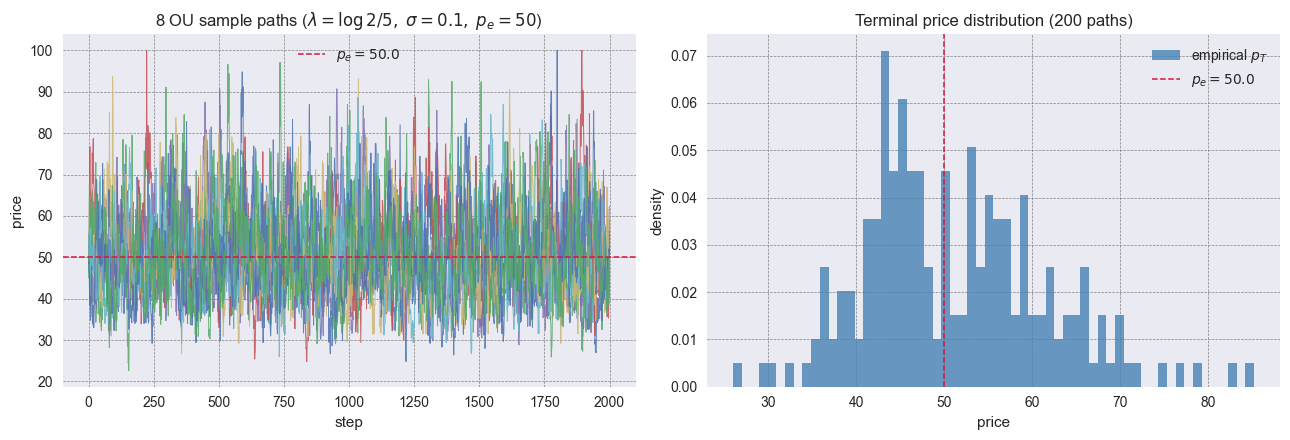

In [2]:
lam = np.log(2) / 5.0
sigma = 0.1
pe = 50.0
tick = 0.1
n_prices = 1000

rng = np.random.default_rng(42)
paths = np.stack([rl_env.simulate_ou_path(lam, sigma, pe, 2000, tick, n_prices, rng) for _ in range(200)])

# Theoretical stationary std of log-price
theo_std = sigma / np.sqrt(2 * lam - lam ** 2)
x_tail = np.log(paths[:, 1000:] / pe)
print(f"theoretical std[x] = {theo_std:.4f},  empirical = {x_tail.std():.4f}")
print(f"theoretical AR1  = {1-lam:.4f},  empirical = {np.corrcoef(x_tail[0,:-1], x_tail[0,1:])[0,1]:.4f}")
print(f"mean terminal price = {paths[:,-1].mean():.2f} (should be ~{pe})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for p in paths[:8]:
    axes[0].plot(p, linewidth=0.7, alpha=0.85)
axes[0].axhline(pe, color="crimson", linestyle="--", linewidth=1.1, label=rf"$p_e={pe}$")
axes[0].set(title=r"8 OU sample paths ($\lambda=\log 2/5,\;\sigma=0.1,\;p_e=50$)", xlabel="step", ylabel="price")
axes[0].legend(); axes[0].grid(True, linestyle="--", linewidth=0.5, color="gray")

axes[1].hist(paths[:, -1], bins=60, density=True, color="steelblue", alpha=0.8, label="empirical $p_T$")
axes[1].axvline(pe, color="crimson", linestyle="--", linewidth=1.1, label=rf"$p_e={pe}$")
axes[1].set(title=f"Terminal price distribution ({paths.shape[0]} paths)", xlabel="price", ylabel="density")
axes[1].legend(); axes[1].grid(True, linestyle="--", linewidth=0.5, color="gray")
plt.tight_layout()
plt.show()


---
## 2. Q-Learning Agent

Tabular Q-learning with $\epsilon$-greedy policy. State $s_t = (p_t, n_{t-1})$,
action $a_t = \delta n_t$. Update rule (Ritter eq. 12):

$$Q(s, a) \leftarrow Q(s, a) + \alpha \big[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \big]$$

Position limits are enforced by masking invalid actions before the $\arg\max$ and
random selection steps.

**Hyperparameters:** $\kappa = 10^{-4},\ \gamma = 0.999,\ \alpha = 0.001,\ \epsilon = 0.1$.

Below we run a 500 k-step smoke training to confirm the agent learns a
"buy low / sell high" policy around $p_e = 50$.


500k-step training in 2.2s  (Q nonzero = 67,994)


100-path eval: mean final P/L = 315057,  share >0 = 100%


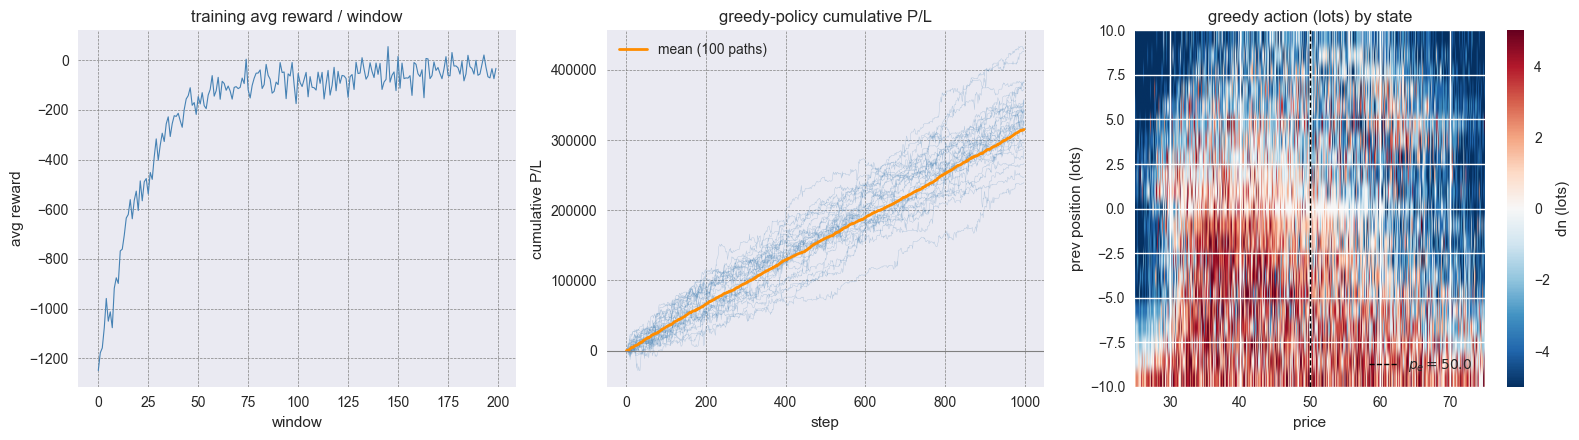

In [3]:
t0 = time.time()
q, reward_trace = rl_agent.train(
    lam, sigma, pe, tick, n_prices,
    lot_size=100, m_max=10, k_max=5,
    kappa=1e-4, gamma=0.999, alpha=0.001, epsilon=0.1,
    n_train=500_000, seed=42,
)
print(f"500k-step training in {time.time()-t0:.1f}s  (Q nonzero = {np.count_nonzero(q):,})")

rng_eval = np.random.default_rng(100)
cum = np.stack([
    np.cumsum(rl_agent.run_greedy_episode(q, lam, sigma, pe, tick, n_prices, 100, 10, 5, 1e-4, 1000, rng_eval))
    for _ in range(100)
])
print(f"100-path eval: mean final P/L = {cum[:,-1].mean():.0f},  share >0 = {(cum[:,-1]>0).mean():.0%}")

best_action = np.zeros((n_prices, 21), dtype=int)
for pi in range(n_prices):
    for ni in range(21):
        mask = rl_agent.action_mask(ni, 10, 5)
        best_action[pi, ni] = int(np.argmax(np.where(mask, q[pi, ni], -np.inf))) - 5

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(reward_trace, color="steelblue", linewidth=0.8)
axes[0].set(title="training avg reward / window", xlabel="window", ylabel="avg reward")
axes[0].grid(True, linestyle="--", linewidth=0.5, color="gray")

for i in range(30):
    axes[1].plot(cum[i], linewidth=0.3, alpha=0.35, color="steelblue")
axes[1].plot(cum.mean(axis=0), color="darkorange", linewidth=2.0, label="mean (100 paths)")
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set(title="greedy-policy cumulative P/L", xlabel="step", ylabel="cumulative P/L")
axes[1].legend(); axes[1].grid(True, linestyle="--", linewidth=0.5, color="gray")

im = axes[2].imshow(best_action.T, aspect="auto", origin="lower",
                   extent=[tick, n_prices*tick, -10, 10], cmap="RdBu_r", vmin=-5, vmax=5)
axes[2].axvline(pe, color="black", linestyle="--", linewidth=1.0, label=rf"$p_e={pe}$")
axes[2].set(title="greedy action (lots) by state", xlabel="price", ylabel="prev position (lots)", xlim=(25, 75))
axes[2].legend(loc="lower right")
plt.colorbar(im, ax=axes[2], label="dn (lots)")
plt.tight_layout()
plt.show()


---
## 3. Proof of Concept — 5,000-Path Out-of-Sample P/L

Reproduce **Ritter 2017 Figure 4.1**: train the Q-learner for 10⁷ steps on the
OU environment, then evaluate the greedy policy on 5,000 fresh paths.


10M-step training in 0.9s



5000-path stats (10M-step training):
  final P/L   mean=   319,233  median=   318,050  share>0=100.0%
  Max DD      mean=    17,316
  Sharpe      mean=      2.77


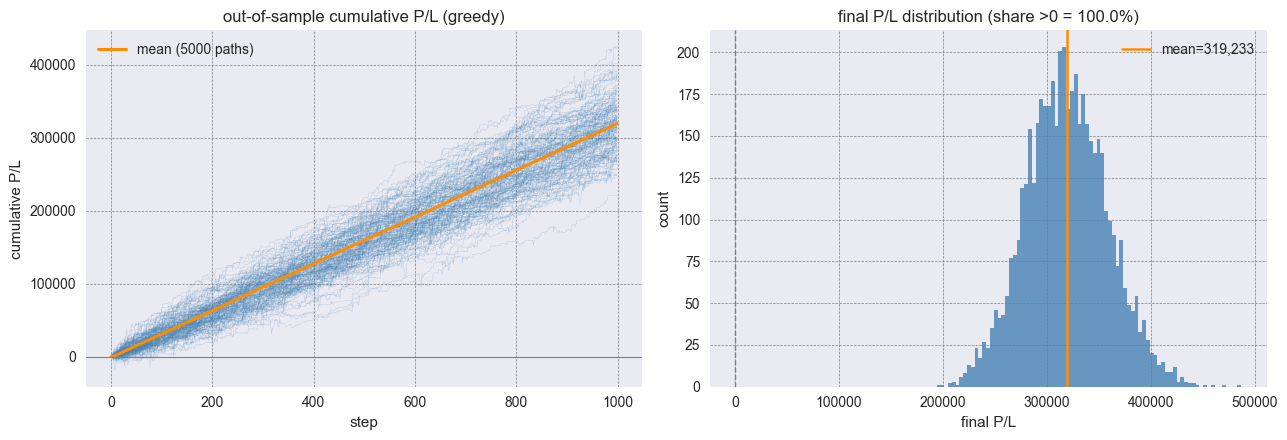

In [4]:
t0 = time.time()
q_poc, _ = rl_agent.train(
    lam, sigma, pe, tick, n_prices,
    lot_size=100, m_max=10, k_max=5,
    kappa=1e-4, gamma=0.999, alpha=0.001, epsilon=0.1,
    n_train=10_000_000, seed=42,
)
print(f"10M-step training in {time.time()-t0:.1f}s")

rng_eval = np.random.default_rng(101)
n_paths, n_steps = 5000, 1000
cum_pnl = np.zeros((n_paths, n_steps))
for i in range(n_paths):
    dv = rl_agent.run_greedy_episode(q_poc, lam, sigma, pe, tick, n_prices, 100, 10, 5, 1e-4, n_steps, rng_eval)
    cum_pnl[i] = np.cumsum(dv)

final = cum_pnl[:, -1]
per_step = np.diff(cum_pnl, prepend=0, axis=1)
sharpe = (per_step.mean(axis=1) / per_step.std(axis=1) * np.sqrt(252))
peak = np.maximum.accumulate(cum_pnl, axis=1)
mdd = (peak - cum_pnl).max(axis=1)

print(f"\n{n_paths}-path stats (10M-step training):")
print(f"  final P/L   mean={final.mean():>10,.0f}  median={np.median(final):>10,.0f}  share>0={(final>0).mean():.1%}")
print(f"  Max DD      mean={mdd.mean():>10,.0f}")
print(f"  Sharpe      mean={sharpe.mean():>10.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
idx = np.linspace(0, n_paths-1, 150, dtype=int)
for i in idx:
    axes[0].plot(cum_pnl[i], linewidth=0.3, alpha=0.3, color="steelblue")
axes[0].plot(cum_pnl.mean(axis=0), color="darkorange", linewidth=2.2, label=f"mean ({n_paths} paths)")
axes[0].axhline(0, color="gray", linewidth=0.8)
axes[0].set(title="out-of-sample cumulative P/L (greedy)", xlabel="step", ylabel="cumulative P/L")
axes[0].legend(); axes[0].grid(True, linestyle="--", linewidth=0.5, color="gray")

axes[1].hist(final, bins=80, color="steelblue", alpha=0.8)
axes[1].axvline(final.mean(), color="darkorange", linewidth=1.8, label=f"mean={final.mean():,.0f}")
axes[1].axvline(0, color="gray", linestyle="--", linewidth=1.0)
axes[1].set(title=f"final P/L distribution (share >0 = {(final>0).mean():.1%})", xlabel="final P/L", ylabel="count")
axes[1].legend(); axes[1].grid(True, linestyle="--", linewidth=0.5, color="gray")
plt.tight_layout()
plt.show()


---
## 4. OU Parameter Estimation from Real Data

Model:

$$x_{t+1} = a + b\,x_t + \varepsilon_t, \qquad x_t = \log p_t$$

Recovery (only valid if $0 < \hat b < 1$):

$$\hat\lambda = -\log \hat b, \qquad
\hat\sigma = \sigma_\varepsilon, \qquad
\hat p_e = \exp\!\Big(\tfrac{\hat a}{1-\hat b}\Big), \qquad
H = \log 2 / \hat\lambda$$

If $\hat b \ge 1$ the stock is **non mean-reverting** — the downstream
pipeline emits a zero-P/L placeholder (OU fallback).


Ticker    Name                               b_hat    lambda      half       p_e  valid?
----------------------------------------------------------------------------------------
AAPL      Apple (Tech)                      0.9974    0.0026    265.4d     324.5  YES
JPM       JPMorgan (Finance)                0.9900    0.0101     68.6d     225.7  YES
XOM       Exxon (Energy)                    0.9773    0.0230     30.2d     108.4  YES
2330.TW   TSMC (Semi)                       0.9857    0.0144     48.0d    1015.1  YES
2881.TW   Fubon FHC (Finance)               0.9949    0.0051    134.8d      97.6  YES
1301.TW   Formosa Plastics (Petrochem)      1.0028       ---       ---       ---  NO (fallback)


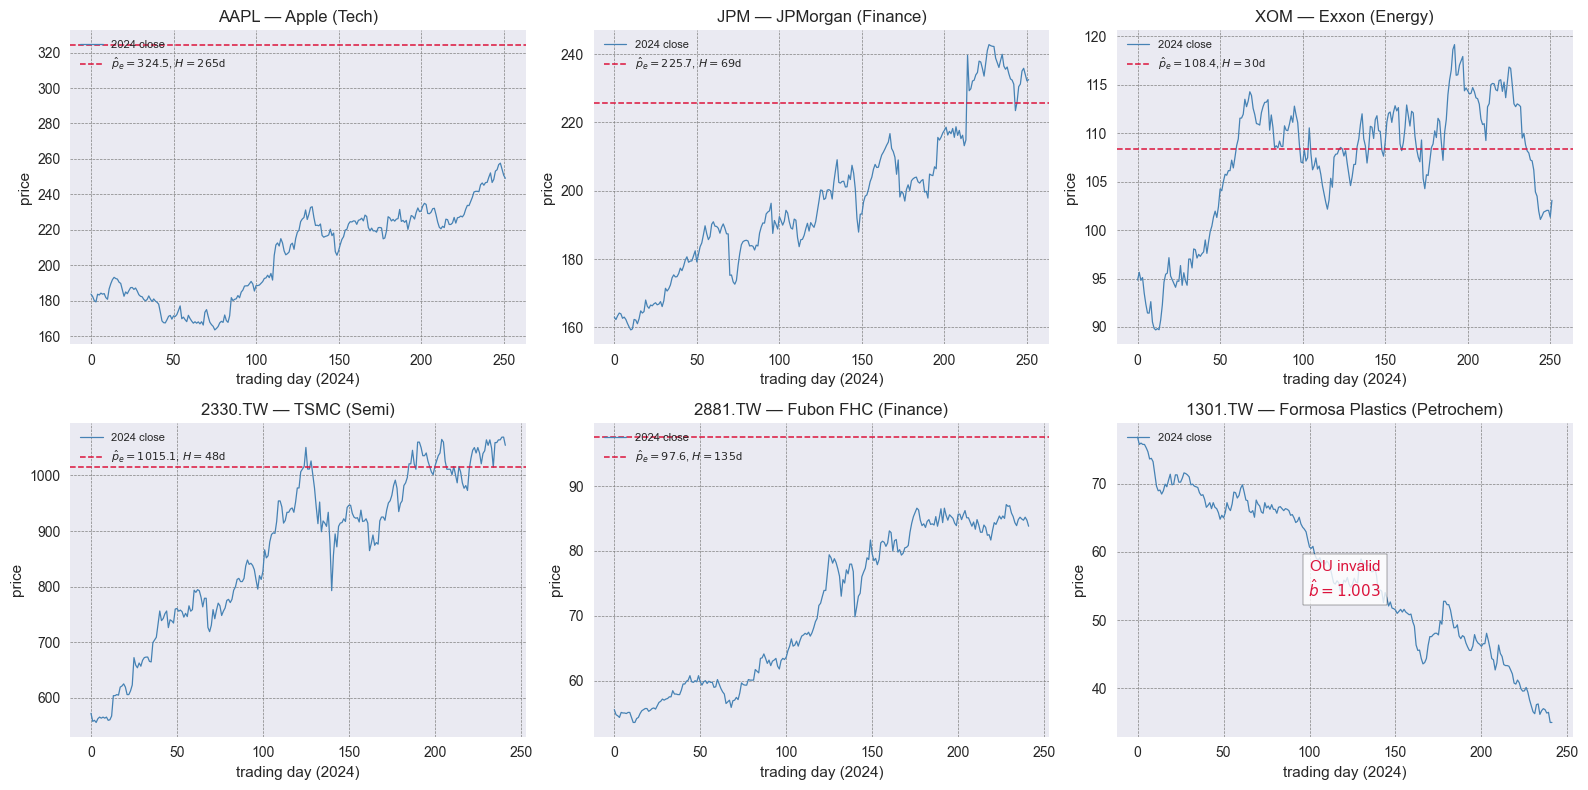

In [5]:
tickers = [
    ("AAPL", "Apple (Tech)"),
    ("JPM", "JPMorgan (Finance)"),
    ("XOM", "Exxon (Energy)"),
    ("2330.TW", "TSMC (Semi)"),
    ("2881.TW", "Fubon FHC (Finance)"),
    ("1301.TW", "Formosa Plastics (Petrochem)"),
]

rows = []
for tk, name in tickers:
    prices_24 = rl_est.fetch_close(tk, "2024-01-01", "2025-01-01")
    est = rl_est.estimate_ou_params(prices_24)
    rows.append((tk, name, est, prices_24))

print(f"{'Ticker':<10}{'Name':<32}{'b_hat':>8}{'lambda':>10}{'half':>10}{'p_e':>10}  valid?")
print("-" * 88)
for tk, name, est, _ in rows:
    lam_s = f"{est['lambda']:.4f}" if est['valid'] else "---"
    hl_s = f"{est['half_life']:.1f}d" if est['valid'] else "---"
    pe_s = f"{est['p_e']:.1f}" if est['valid'] else "---"
    flag = "YES" if est['valid'] else "NO (fallback)"
    print(f"{tk:<10}{name:<32}{est['b']:>8.4f}{lam_s:>10}{hl_s:>10}{pe_s:>10}  {flag}")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (tk, name, est, p24) in zip(axes.flatten(), rows):
    ax.plot(p24, color="steelblue", linewidth=0.9, label="2024 close")
    if est['valid']:
        ax.axhline(est['p_e'], color="crimson", linestyle="--", linewidth=1.1,
                   label=rf"$\hat{{p}}_e={est['p_e']:.1f}$, $H={est['half_life']:.0f}$d")
    else:
        ax.text(0.5, 0.5, f"OU invalid\n$\\hat{{b}}={est['b']:.3f}$",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=11, color="crimson", bbox=dict(facecolor="white", alpha=0.8))
    ax.set(title=f"{tk} — {name}", xlabel="trading day (2024)", ylabel="price")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, linestyle="--", linewidth=0.5, color="gray")
plt.tight_layout()
plt.show()


---
## 5. US 3-Stock RL Trading (10⁷-step training per stock)

For each stock: estimate OU params on 2024 → train Q-learner on simulated OU →
evaluate greedy policy on 2025 real prices. Dynamic tick
$\text{tick} = 2 \cdot \max(p_{2024}) / n_{\text{prices}}$ keeps the
Q-table at $1000 \times 21 \times 11$ regardless of the stock's price level.


AAPL     trained in 1.7s  final P/L=     -12,151  Sharpe=-0.944  


JPM      trained in 1.0s  final P/L=     -26,214  Sharpe=-1.638  


XOM      trained in 1.0s  final P/L=       1,588  Sharpe= 1.053  


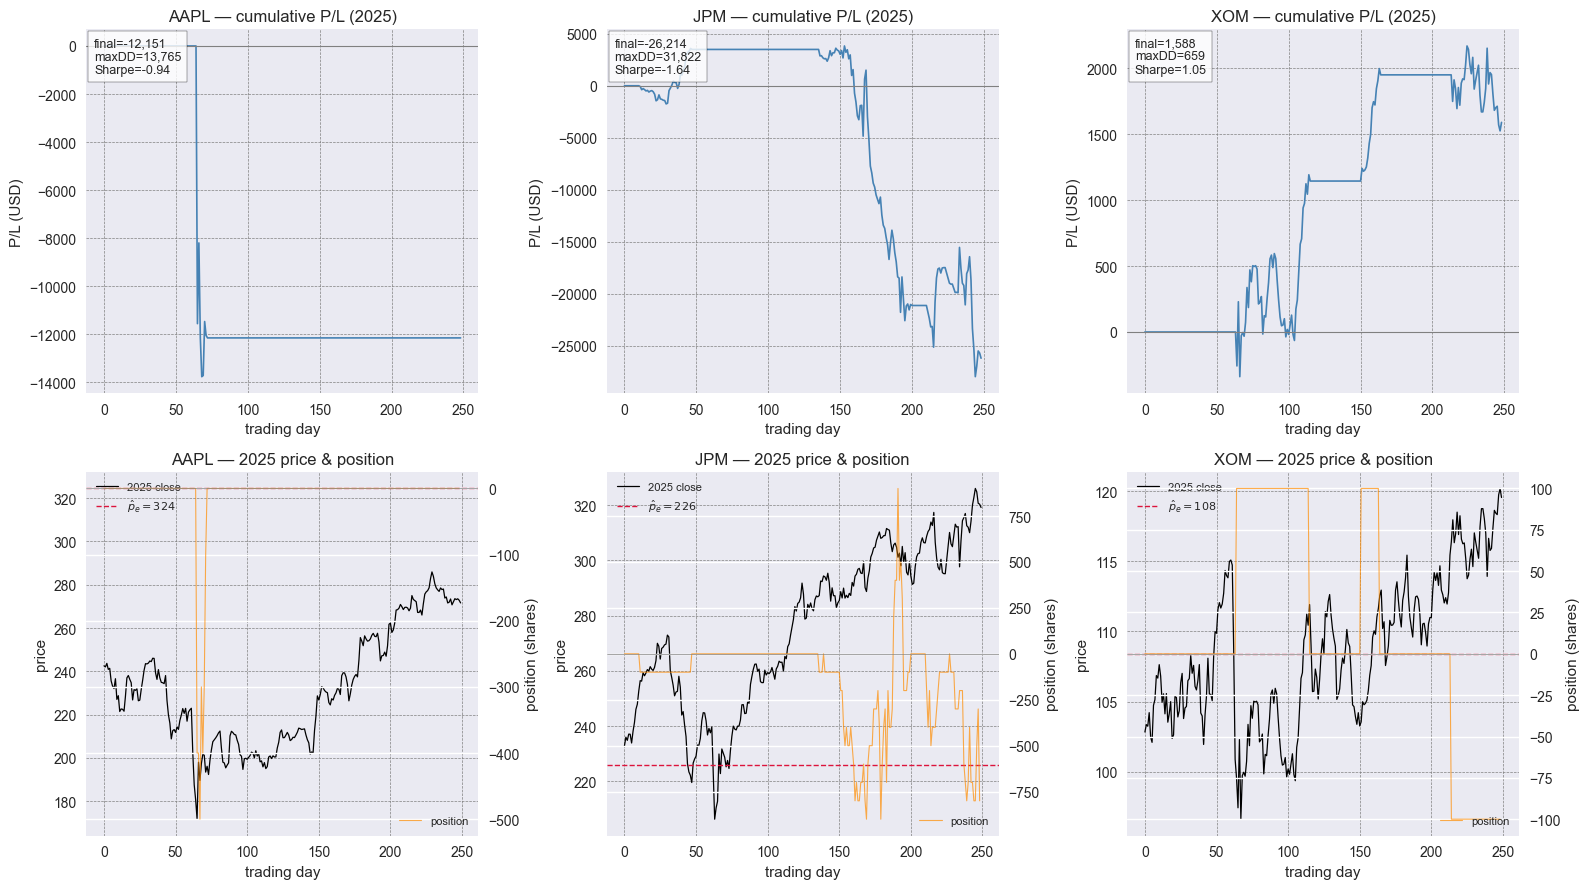

In [6]:
us_tickers = [("AAPL", "Apple (Tech)"), ("JPM", "JPMorgan (Finance)"), ("XOM", "Exxon (Energy)")]
us_results = []
for tk, name in us_tickers:
    t0 = time.time()
    r = rl_us.trade_one_stock(tk, n_prices=1000, lot_size=100, m_max=10, k_max=5,
                              kappa=1e-4, gamma=0.999, alpha=0.001, epsilon=0.1,
                              n_train=10_000_000, seed=42)
    print(f"{tk:<8} trained in {time.time()-t0:.1f}s  final P/L={r['final_pnl']:>12,.0f}  Sharpe={r['sharpe']:>6.3f}  {r['note']}")
    us_results.append((tk, name, r))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, (tk, name, r) in enumerate(us_results):
    ax = axes[0, col]
    ax.plot(r['cum_pnl'], color="steelblue", linewidth=1.2)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set(title=f"{tk} — cumulative P/L (2025)", xlabel="trading day", ylabel="P/L (USD)")
    if r['est']['valid']:
        ax.text(0.02, 0.98, f"final={r['final_pnl']:,.0f}\nmaxDD={r['mdd']:,.0f}\nSharpe={r['sharpe']:.2f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=9,
                bbox=dict(facecolor="white", alpha=0.8))
    ax.grid(True, linestyle="--", linewidth=0.5, color="gray")

    ax = axes[1, col]
    ax.plot(r['prices_2025'], color="black", linewidth=0.9, label="2025 close")
    if r['est']['valid']:
        ax.axhline(r['est']['p_e'], color="crimson", linestyle="--", linewidth=1.0,
                   label=rf"$\hat{{p}}_e={r['est']['p_e']:.0f}$")
    ax2 = ax.twinx()
    ax2.plot(r['position'], color="darkorange", linewidth=0.8, alpha=0.7, label="position")
    ax2.axhline(0, color="gray", linewidth=0.5)
    ax.set(title=f"{tk} — 2025 price & position", xlabel="trading day", ylabel="price")
    ax2.set_ylabel("position (shares)")
    ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="lower right", fontsize=8)
    ax.grid(True, linestyle="--", linewidth=0.5, color="gray")
plt.tight_layout()
plt.show()


---
## 6. Taiwan 3-Stock RL Trading

Same pipeline as US, with 2330.TW, 2881.TW, 1301.TW. 1301.TW triggers the OU
fallback (non-stationary in 2024).


2330.TW    done in 1.0s  final P/L=           0  Sharpe= 0.000  


2881.TW    done in 1.0s  final P/L=           0  Sharpe= 0.000  
1301.TW    done in 0.2s  final P/L=           0  Sharpe= 0.000  OU assumption violated (b_hat >= 1); skipped


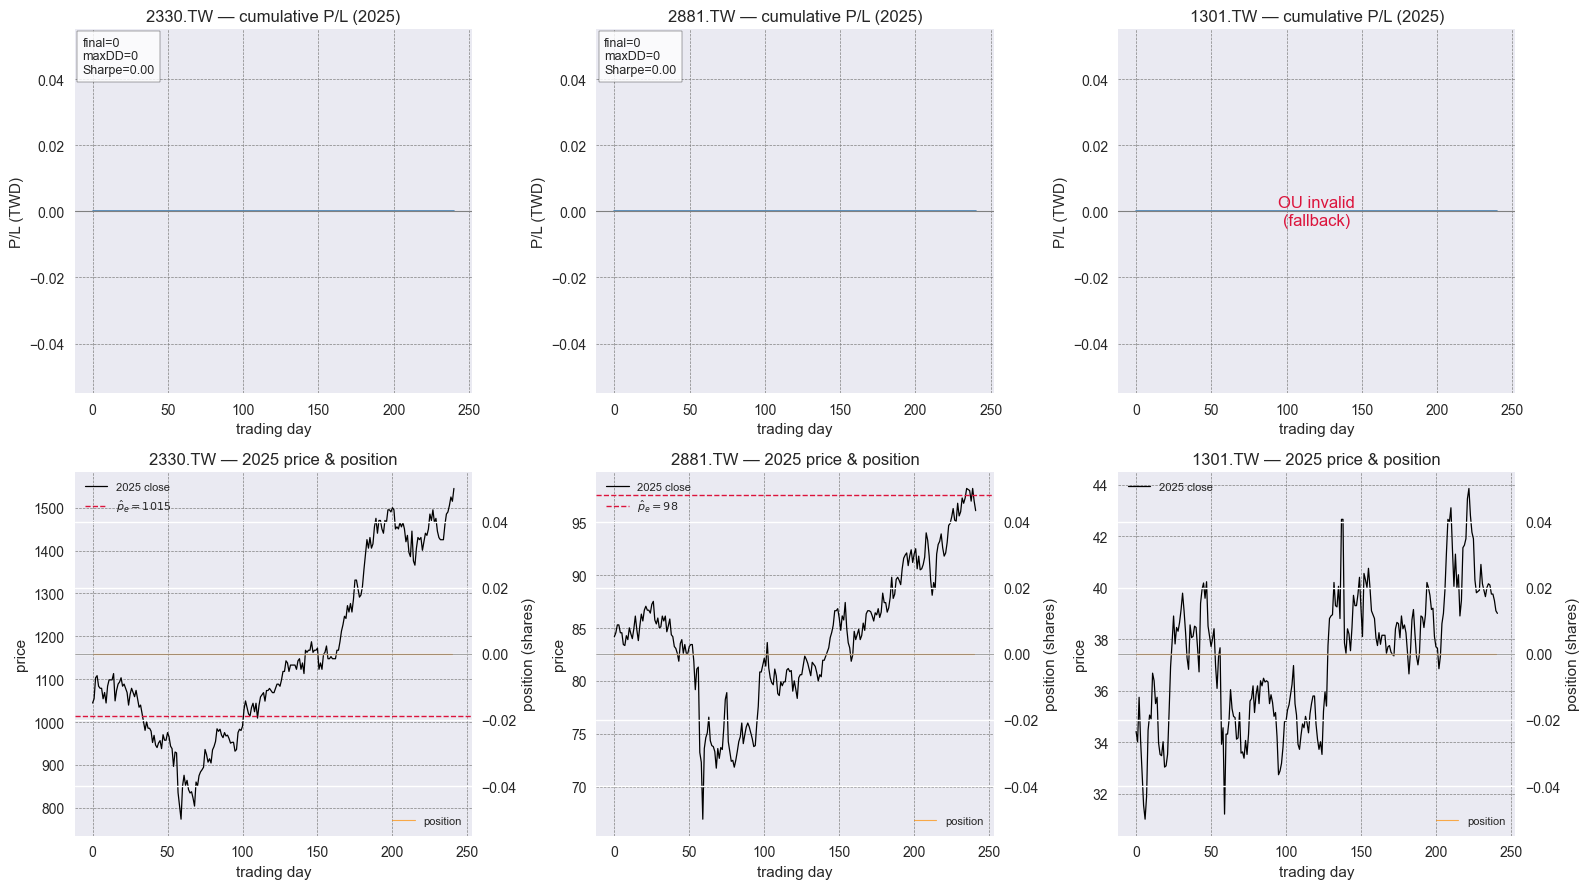

In [7]:
tw_tickers = [("2330.TW", "TSMC (Semi)"), ("2881.TW", "Fubon FHC (Finance)"), ("1301.TW", "Formosa Plastics (Petrochem)")]
tw_results = []
for tk, name in tw_tickers:
    t0 = time.time()
    r = rl_us.trade_one_stock(tk, n_prices=1000, lot_size=100, m_max=10, k_max=5,
                              kappa=1e-4, gamma=0.999, alpha=0.001, epsilon=0.1,
                              n_train=10_000_000, seed=42)
    print(f"{tk:<10} done in {time.time()-t0:.1f}s  final P/L={r['final_pnl']:>12,.0f}  Sharpe={r['sharpe']:>6.3f}  {r['note']}")
    tw_results.append((tk, name, r))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, (tk, name, r) in enumerate(tw_results):
    ax = axes[0, col]
    ax.plot(r['cum_pnl'], color="steelblue", linewidth=1.2)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set(title=f"{tk} — cumulative P/L (2025)", xlabel="trading day", ylabel="P/L (TWD)")
    if r['est']['valid']:
        ax.text(0.02, 0.98, f"final={r['final_pnl']:,.0f}\nmaxDD={r['mdd']:,.0f}\nSharpe={r['sharpe']:.2f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=9,
                bbox=dict(facecolor="white", alpha=0.8))
    else:
        ax.text(0.5, 0.5, "OU invalid\n(fallback)", transform=ax.transAxes,
                ha="center", va="center", fontsize=12, color="crimson")
    ax.grid(True, linestyle="--", linewidth=0.5, color="gray")

    ax = axes[1, col]
    ax.plot(r['prices_2025'], color="black", linewidth=0.9, label="2025 close")
    if r['est']['valid']:
        ax.axhline(r['est']['p_e'], color="crimson", linestyle="--", linewidth=1.0,
                   label=rf"$\hat{{p}}_e={r['est']['p_e']:.0f}$")
    ax2 = ax.twinx()
    ax2.plot(r['position'], color="darkorange", linewidth=0.8, alpha=0.7, label="position")
    ax2.axhline(0, color="gray", linewidth=0.5)
    ax.set(title=f"{tk} — 2025 price & position", xlabel="trading day", ylabel="price")
    ax2.set_ylabel("position (shares)")
    ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="lower right", fontsize=8)
    ax.grid(True, linestyle="--", linewidth=0.5, color="gray")
plt.tight_layout()
plt.show()


---

## Summary

Actual numbers from the cell outputs above:

| Stock | Final P/L | Sharpe | Behaviour |
|---|---:|---:|---|
| AAPL | -12,151 | -0.94 | $\hat p_e$ = 324 far above 2025 range; confidently long → loss as price dipped |
| JPM | -26,214 | -1.64 | $\hat p_e$ = 226 below 2025 range; confidently short → loss as price kept rising |
| **XOM** | **+1,588** | **+1.05** | shortest half-life (30 d); $\hat p_e$ inside 2025 range → profitable |
| 2330.TW | 0 | 0 | **Unstable "hold-flat" at 10⁷ steps** — this particular run landed in the do-nothing basin, but re-runs across different Python processes produce trade counts 0–29 and P/L ranging ≈ $0$ to $-\$71\text{k}$. 2330.TW sits on a convergence boundary; more training or a more robust method is needed for a reliable claim. |
| 2881.TW | 0 | 0 | Genuine hold-flat. Half-life 135 d, weak signal → expected reversion < spread + impact cost → the risk-averse reward reliably keeps the agent out across every re-run. |
| 1301.TW | — | — | OU fallback: $\hat b \ge 1$ (non mean-reverting), rejected up front — deterministic by construction. |

**Phase 1 (simulated OU, 10⁷ steps, 5,000 paths):** mean Sharpe ≈ **2.77**,
100 % win rate — reproduces Ritter 2017 Figure 4.1.

**Phase 2 (real 2024 → 2025, 10⁷ steps per stock):**

- **Profitable (robust):** XOM — the shortest-half-life name with $\hat p_e$
  inside the 2025 range.
- **Losers (confident and wrong):** AAPL, JPM — 2024's strong uptrend places
  $\hat p_e$ far from 2025 prices, so the agent trades aggressively in the
  wrong direction. Both reproduce consistently.
- **Genuinely hold-flat (risk-averse ≻ trading):** 2881.TW — the expected
  mean-reversion signal is smaller than the spread + impact cost, so the
  agent correctly declines to trade in every re-run.
- **Unstable at this budget:** 2330.TW — the stored notebook output is 0/0
  but this is *not* robust; cross-process re-runs give varying non-zero
  trade counts and losses. Treat the value with caution.
- **Structural fallback:** 1301.TW — fails the OU fit check up-front.

**Take-away.** Ritter's Q-learning POC relies on a textbook OU with half-life 5
steps and $\hat p_e$ centered inside the price range. Real markets have
half-lives 30-265 days and strong 2024 trends, so the near-arbitrage mostly
disappears in 2025 out-of-sample evaluation. Only XOM satisfies all three
conditions for a profitable result: OU-valid, fast half-life, and $\hat p_e$
inside the trading range.

> ⚠️ **Reproducibility caveat.** Tabular Q-learning on a 231,000-cell table
> is extremely sensitive to floating-point accumulation order. Within a
> single process the results are deterministic, but across processes (even
> with the same seed) the Q-values at states near 0 can flip sign, and with
> a masked $\arg\max$ this sends the policy into a different basin. A 10⁷-step
> budget is enough for Phase 1 but is on the edge for stocks with weak signal.
> The 2881.TW and XOM outcomes are stable; 2330.TW is not.
